In [1]:
from ml_recon.models.modl import modl
from torch.utils.data import DataLoader
from ml_recon.transforms import (pad, toTensor, normalize)
from ml_recon.dataset.undersampled_slice_loader import UndersampledSliceDataset
from torchvision.transforms import Compose
import numpy as np

import torch
from ml_recon.utils import image_slices, save_model
from ml_recon.utils.collate_function import collate_fn
from ml_recon.models.varnet import VarNet

In [2]:
torch.manual_seed(0)
np.random.seed(0)

In [5]:
transforms = Compose(
    (
        pad((640, 320)), 
        toTensor(),
        normalize(),
    )
)
dataset = UndersampledSliceDataset('/home/kadotab/val_16_header.json', transforms=transforms, R=4)
dataloader = DataLoader(dataset, batch_size=1, collate_fn=collate_fn)
    

In [6]:
data = next(iter(dataloader))

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [8]:
model = VarNet(2, 2, num_cascades=5, use_norm=True)
model.to(device)

VarNet(
  (cascade): ModuleList(
    (0): VarnetBlock(
      (unet): NormUnet(
        (unet): Unet(
          (down_sample_layers): ModuleList(
            (0): double_conv(
              (conv1): Conv2d(2, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (conv2): Conv2d(18, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (activation): LeakyReLU(negative_slope=0.2, inplace=True)
              (instance_norm1): InstanceNorm2d(18, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
              (instance_norm2): InstanceNorm2d(18, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
              (drop_out1): Dropout2d(p=0, inplace=False)
              (drop_out2): Dropout2d(p=0, inplace=False)
            )
            (1): Unet_down(
              (down): down(
                (max_pool): AvgPool2d(kernel_size=2, stride=(2, 2), padding=0)
              )
              (conv): double_conv(
    

In [12]:
from ml_recon.utils.load_checkpoint import load_checkpoint

model, optim = load_checkpoint('/home/kadotab/python/ml/ml_recon/Model_Weights/20230516-124015VarNet.pt', model, optimizer)

In [13]:
sense = model.sens_model(data['k_space'].to(device))

In [20]:
output = model(data['k_space'].to(device), data['mask'].to(device))

In [18]:
import matplotlib.pyplot as plt
from ml_recon.utils import ifft_2d_img

(<Figure size 1000x1000 with 12 Axes>,
 array([[<AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >],
        [<AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >],
        [<AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >],
        [<AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >]], dtype=object))

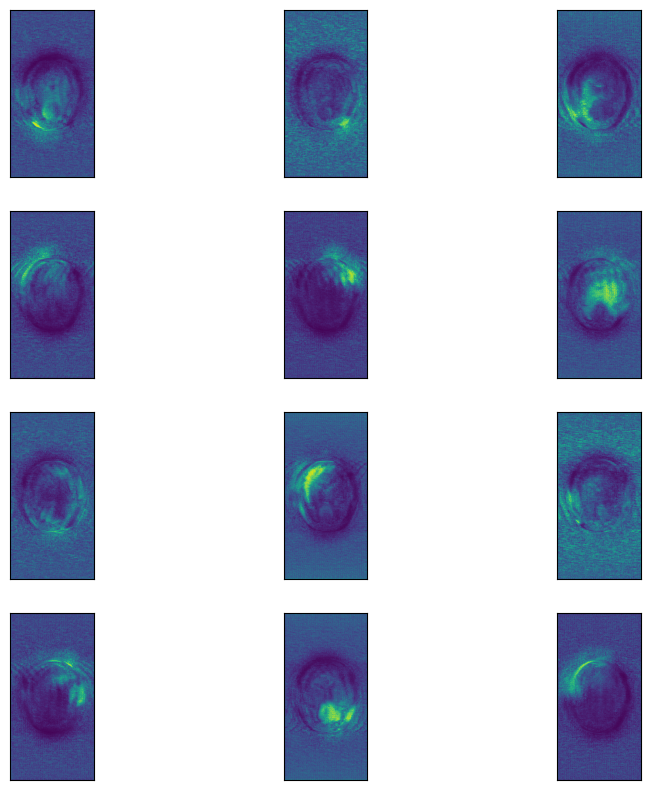

In [14]:
image_slices(sense.cpu().detach()[0])

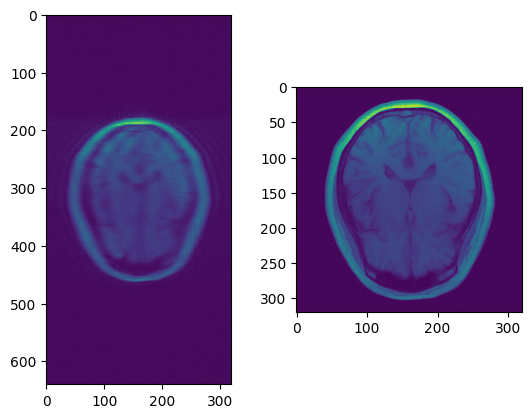

In [25]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(ifft_2d_img(output.cpu().detach()[0]).abs().pow(2).sum(0).sqrt())
ax[1].imshow(data['recon'][0])

tensor(1.3038)

In [11]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
writer = SummaryWriter('/home/kadotab/scratch/runs/' +  datetime.now().strftime("%Y%m%d-%H%M%S"))

In [7]:
path = '/home/kadotab/python/ml/ml_recon/Model_Weights/'
def train(model, loss_function, optimizer, dataloader, epoch=7):
    cur_loss = 0
    for e in range(epoch):
        for data in dataloader:
            sampled = data['k_space']
            mask = data['mask']
            undersampled = data['undersampled']
            optimizer.zero_grad()
            mask_slice = mask.to(device)
            undersampled_slice = undersampled.to(device)
            sampled_slice = sampled.to(device)

            predicted_sampled = model(undersampled_slice, mask_slice)
            loss = loss_function(torch.view_as_real(predicted_sampled), torch.view_as_real(sampled_slice))

            loss.backward()
            optimizer.step()
            cur_loss += loss.item()
              
        writer.add_histogram('sens/weights1', next(model.sens_model.model.conv1d.parameters()), e)
        writer.add_histogram('castcade0/weights1', next(model.cascade[0].unet.conv1d.parameters()), e)
        writer.add_histogram('castcade0/weights2', next(model.cascade[1].unet.conv1d.parameters()), e)
        writer.add_histogram('castcade0/weights11', next(model.cascade[-2].unet.conv1d.parameters()), e)
        writer.add_histogram('castcade0/weights12', next(model.cascade[-1].unet.conv1d.parameters()), e)
        writer.add_histogram('varnet/regularizer', model.lambda_reg.data, e)
        writer.add_scalar('Loss/train', cur_loss, e)
        print(f"Iteration: {e + 1:>d}, Loss: {cur_loss:>7f}")
        cur_loss = 0
        save_model(path, model, optimizer, e) 
    save_model(path, model, optimizer, -1)

In [8]:
train(model, loss_fn, optimizer, dataloader, 50)